<a href="https://colab.research.google.com/github/MiguelCortezPino/dataset/blob/main/Parcial04Asociacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
# -------------------------------------------------------------------------
# BLOQUE 1: Importación de librerías y carga de datos desde GitHub
# -------------------------------------------------------------------------
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# Ruta de tu dataset almacenada en la nube en GitHub
url = "https://raw.githubusercontent.com/MiguelCortezPino/dataset/refs/heads/main/Parcial04/clave_H_asociacion.csv"

# Cargamos el archivo CSV directamente usando la URL
df_asoc = pd.read_csv(url)

# Mostramos las primeras 5 filas para comprobar que cargó bien
print("--- PRIMERAS FILAS DEL DATASET ---")
print(df_asoc.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

--- PRIMERAS FILAS DEL DATASET ---
  transaccion_id cliente_id       fecha      categoria           item  \
0        H-T0001    H-C0026  2026-04-10          Cloud   Backup_cloud   
1        H-T0001    H-C0026  2026-04-10  Productividad            CRM   
2        H-T0001    H-C0026  2026-04-10      Educacion  Certificacion   
3        H-T0001    H-C0026  2026-04-10  Productividad          Notas   
4        H-T0002    H-C0038  2026-03-16  Productividad            CRM   

   cantidad   canal  
0         2     Web  
1         2     Web  
2         1     Web  
3         1     Web  
4         1  Tienda  


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [26]:
# -------------------------------------------------------------------------
# BLOQUE 2: Diagnóstico y limpieza de los datos
# -------------------------------------------------------------------------
print("\n--- ESTRUCTURA Y TIPOS DE DATOS ---")
df_asoc.info()

print("\n--- VALORES NULOS POR COLUMNA ---")
print(df_asoc.isnull().sum())

print("\n--- CANTIDAD DE REGISTROS DUPLICADOS ---")
print(df_asoc.duplicated().sum())

# Limpieza: Rellenamos el valor vacío en 'canal' y eliminamos filas duplicadas [cite: 1]
df_asoc['canal'] = df_asoc['canal'].fillna('Desconocido')
df_asoc = df_asoc.drop_duplicates()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


--- ESTRUCTURA Y TIPOS DE DATOS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 624 entries, 0 to 623
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaccion_id  624 non-null    object
 1   cliente_id      624 non-null    object
 2   fecha           624 non-null    object
 3   categoria       624 non-null    object
 4   item            624 non-null    object
 5   cantidad        624 non-null    int64 
 6   canal           623 non-null    object
dtypes: int64(1), object(6)
memory usage: 34.3+ KB

--- VALORES NULOS POR COLUMNA ---
transaccion_id    0
cliente_id        0
fecha             0
categoria         0
item              0
cantidad          0
canal             1
dtype: int64

--- CANTIDAD DE REGISTROS DUPLICADOS ---
1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [27]:
# -------------------------------------------------------------------------
# BLOQUE 3: Transformación a matriz transaccional (One-Hot Encoding)
# -------------------------------------------------------------------------
# Agrupamos por transaccion_id e item [cite: 1]
basket = (df_asoc.groupby(['transaccion_id', 'item'])['cantidad']
          .sum().unstack().reset_index().fillna(0)
          .set_index('transaccion_id'))

# Convertimos a formato binario: 1 si el producto está en la transacción, 0 si no.
def encode_units(x):
    return 1 if x >= 1 else 0

basket_sets = basket.applymap(encode_units)
print("\n--- VISTA DE LA MATRIZ TRANSACCIONAL ---")
print(basket_sets.head(3))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


--- VISTA DE LA MATRIZ TRANSACCIONAL ---
item            Agenda  Almacenamiento  Antivirus  Backup_cloud  CRM  \
transaccion_id                                                         
H-T0001              0               0          0             1    1   
H-T0002              0               0          0             0    1   
H-T0003              0               1          0             1    0   

item            Certificacion  Colaboracion  Curso_excel  Curso_ingles  \
transaccion_id                                                           
H-T0001                     1             0            0             0   
H-T0002                     1             0            0             1   
H-T0003                     0             0            0             0   

item            Curso_python  Dominio  Gestor_password  Hosting  Monitoreo  \
transaccion_id                                                               
H-T0001                    0        0                0        0       

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [31]:
# -------------------------------------------------------------------------
# BLOQUE 4: Aplicación de Apriori y Generación de Reglas
# -------------------------------------------------------------------------
# Buscamos conjuntos de productos frecuentes con un soporte mínimo del 5%
frequent_itemsets = apriori(basket_sets, min_support=0.05, use_colnames=True)

# Generamos las reglas basándonos en la métrica de confianza
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)

# Ordenamos por las reglas más fuertes (Lift alto y Confianza alta) y mostramos las top 10
top_10_rules = rules.sort_values(by=['lift', 'confidence'], ascending=[False, False]).head(10)

print("\n--- LAS 10 REGLAS MÁS RELEVANTES ---")
print(top_10_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


--- LAS 10 REGLAS MÁS RELEVANTES ---
          antecedents        consequents  support  confidence      lift
20  (Gestor_password)              (VPN)    0.125    0.641026  2.616431
21              (VPN)  (Gestor_password)    0.125    0.510204  2.616431
19          (Dominio)          (Hosting)    0.105    0.567568  2.522523
18          (Hosting)          (Dominio)    0.105    0.466667  2.522523
22    (Plan_familiar)       (Plan_video)    0.140    0.651163  2.457218
23       (Plan_video)    (Plan_familiar)    0.140    0.528302  2.457218
7      (Curso_python)    (Certificacion)    0.140    0.583333  2.287582
6     (Certificacion)     (Curso_python)    0.140    0.549020  2.287582
5               (CRM)    (Certificacion)    0.050    0.434783  1.705030
4     (Certificacion)              (CRM)    0.050    0.196078  1.705030


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

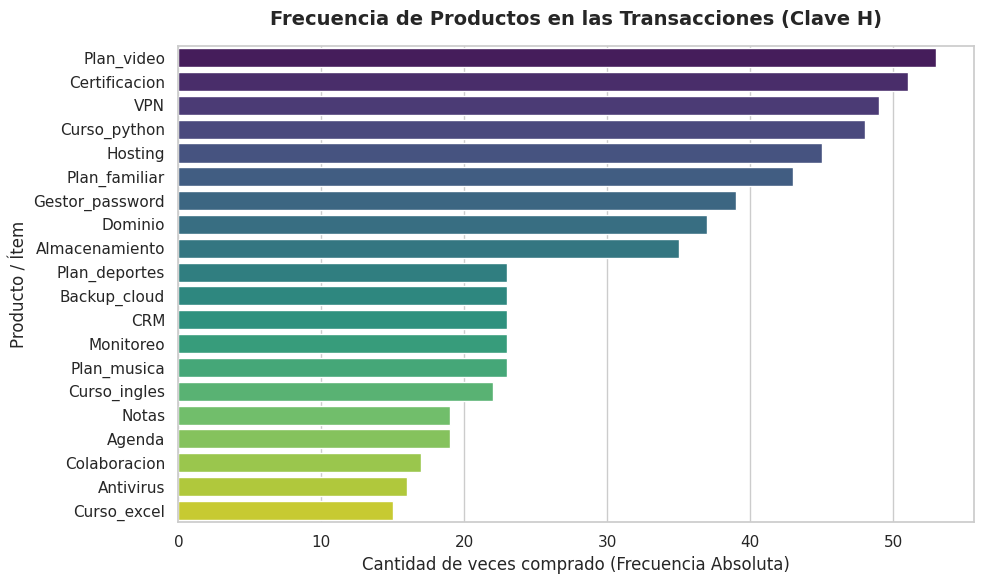

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [29]:
# -------------------------------------------------------------------------
# BLOQUE ADICIONAL: Visualización de Frecuencia de Productos
# -------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Contamos cuántas veces aparece cada producto en el dataset limpio
frecuencia_items = df_asoc['item'].value_counts()

# Configuramos el estilo visual con Seaborn
sns.set_theme(style="whitegrid")

# Creamos una gráfica de barras horizontales para que los nombres se lean perfectamente
plt.figure(figsize=(10, 6))
sns.barplot(
    x=frecuencia_items.values,
    y=frecuencia_items.index,
    palette="viridis",
    hue=frecuencia_items.index,
    legend=False
)

# Añadimos títulos y etiquetas claras
plt.title('Frecuencia de Productos en las Transacciones (Clave H)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cantidad de veces comprado (Frecuencia Absoluta)', fontsize=12)
plt.ylabel('Producto / Ítem', fontsize=12)

# Ajustamos los márgenes para que no se corte ningún texto
plt.tight_layout()

# Desplegamos la gráfica en el Notebook
plt.show()